The Road map
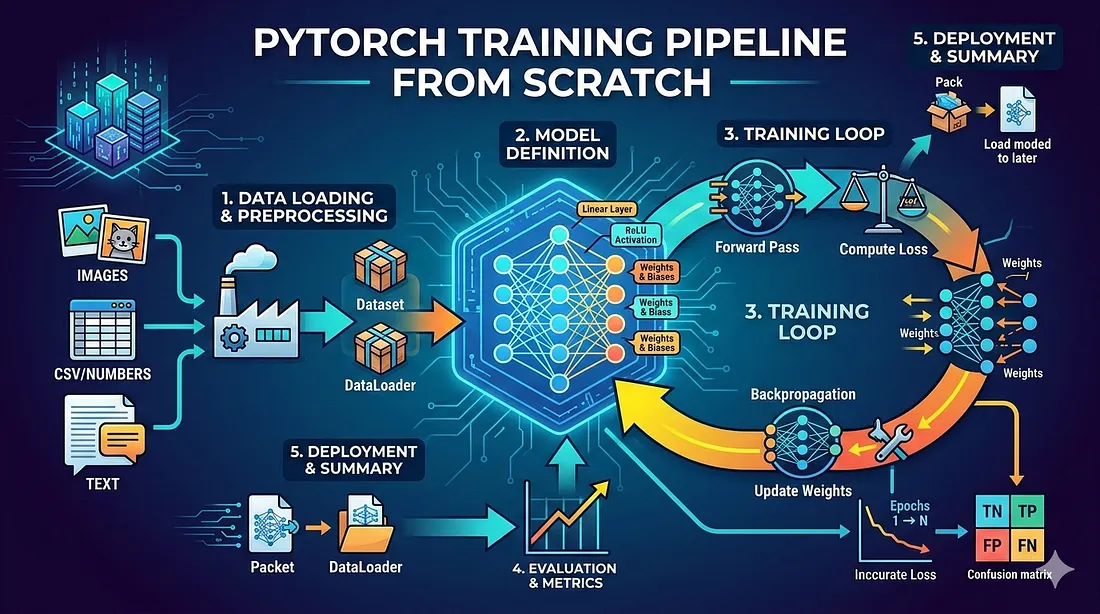

In [69]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing  import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

#Data Loading & Preprocessing

In [70]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [71]:
df.shape

(569, 33)

In [72]:
df.drop(columns=['id','Unnamed: 32'],inplace=True)

In [73]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [74]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

In [75]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [76]:
X_train

array([[ 0.21125611,  0.71852343,  0.40746888, ...,  2.01822576,
        -0.05052796,  1.74031901],
       [-0.6354086 ,  0.49132748, -0.64690308, ..., -0.65399696,
        -0.7403635 ,  0.08313546],
       [-1.22094709, -0.47652729, -1.20810772, ..., -0.90728026,
         0.14771917, -0.55627634],
       ...,
       [-0.7465868 , -1.96466078, -0.76236032, ..., -1.04056315,
         0.79403706, -0.52653626],
       [-0.38454498, -1.43302225, -0.45062578, ..., -1.15125054,
        -1.79606976, -0.58987162],
       [ 0.0972272 , -1.92603747,  0.08501332, ...,  0.10371551,
        -0.01345735, -0.21151167]])

In [77]:
y_train

,diagnosis
430,M
115,B
206,B
102,B
96,B
...,...
472,B
246,B
313,B
179,B


#Label Encoding

In [78]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [79]:
y_train

array([1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,

#Numpy to PyTorch Tensors

In [80]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)
y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)

In [81]:
X_train_tensor.shape

torch.Size([455, 30])

In [82]:
y_train_tensor.shape

torch.Size([455])

# Defining the Model


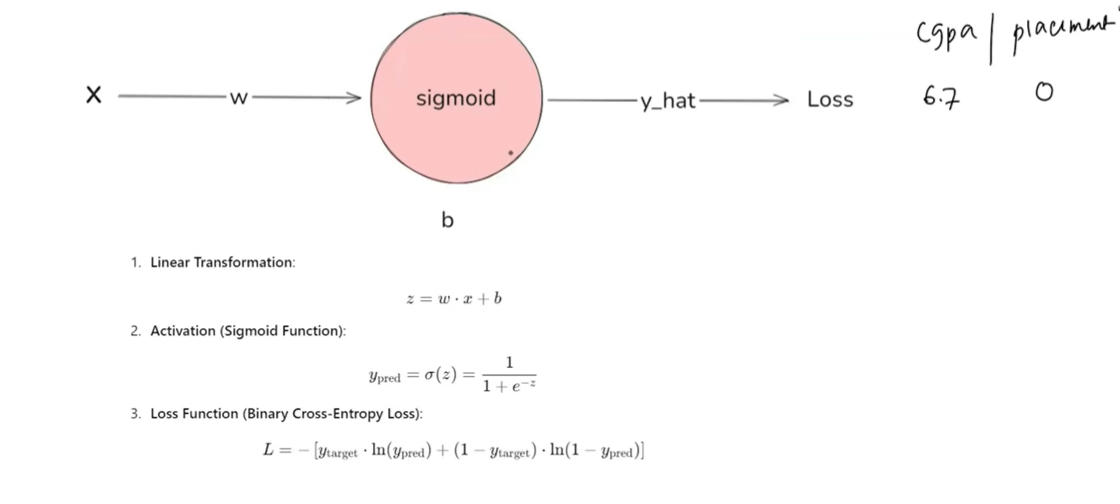

#Defining the Mode

In [83]:
class MySimpleNN():
    def __init__(self, X):
      self.weight=torch.rand(X.shape[1],1,dtype=torch.float32,requires_grad=True)
      self.bias=torch.rand(1,dtype=torch.float32,requires_grad=True)

    def forward(self,X):
      z=torch.matmul(X,self.weight)+self.bias
      y_pred=torch.sigmoid(z)
      return y_pred

    def loss_function(self, y_pred, y):
      epsilon = 1e-7
      y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
      loss = -(y_train_tensor * torch.log(y_pred) + (1 - y_train_tensor) * torch.log(1 - y_pred)).mean()
      return loss


#Hyperparameters

In [84]:
learning_rate=0.1
epochs=25

#Training Pipeline

In [87]:
X_train_tensor = X_train_tensor.float()
y_train_tensor = y_train_tensor.float()

model = MySimpleNN(X_train_tensor)

for epoch in range(epochs):
  y_pred = model.forward(X_train_tensor)
  loss = model.loss_function(y_pred, y_train_tensor)
  loss.backward()

  with torch.no_grad():
    model.weight -= learning_rate * model.weight.grad
    model.bias -= learning_rate * model.bias.grad

  model.weight.grad.zero_()
  model.bias.grad.zero_()

  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

Epoch: 1, Loss: 3.5520825386047363
Epoch: 2, Loss: 3.4360148906707764
Epoch: 3, Loss: 3.3202197551727295
Epoch: 4, Loss: 3.1923305988311768
Epoch: 5, Loss: 3.0621156692504883
Epoch: 6, Loss: 2.929954767227173
Epoch: 7, Loss: 2.7944765090942383
Epoch: 8, Loss: 2.66226863861084
Epoch: 9, Loss: 2.5134503841400146
Epoch: 10, Loss: 2.3635151386260986
Epoch: 11, Loss: 2.2160537242889404
Epoch: 12, Loss: 2.074023723602295
Epoch: 13, Loss: 1.9358775615692139
Epoch: 14, Loss: 1.8015516996383667
Epoch: 15, Loss: 1.6765753030776978
Epoch: 16, Loss: 1.5593503713607788
Epoch: 17, Loss: 1.4524658918380737
Epoch: 18, Loss: 1.3577216863632202
Epoch: 19, Loss: 1.276171326637268
Epoch: 20, Loss: 1.207068920135498
Epoch: 21, Loss: 1.1460931301116943
Epoch: 22, Loss: 1.0951950550079346
Epoch: 23, Loss: 1.0506958961486816
Epoch: 24, Loss: 1.0145139694213867
Epoch: 25, Loss: 0.9842500686645508


#Model Evaluation

In [ ]:
with torch.no_grad():
  y_pred=model.forward(X_test_tensor)
  y_pred=(y_pred>0.9).float()
  accuracy=(y_pred==y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

In [90]:
y_pred

tensor([[0.0758],
        [0.2535],
        [0.3759],
        [0.4702],
        [0.6253],
        [0.1024],
        [0.1145],
        [0.2312],
        [1.0000],
        [0.6223],
        [0.7583],
        [0.4237],
        [0.6709],
        [0.7008],
        [0.3537],
        [0.3952],
        [0.8701],
        [0.9476],
        [0.4193],
        [0.1367],
        [0.2629],
        [0.1837],
        [0.9762],
        [0.4228],
        [0.4250],
        [0.5230],
        [0.5377],
        [0.1842],
        [0.7911],
        [0.6569],
        [0.9334],
        [0.7463],
        [0.3508],
        [0.4180],
        [0.6797],
        [0.1087],
        [0.3463],
        [0.6102],
        [0.6546],
        [0.3665],
        [0.3918],
        [0.3265],
        [0.4252],
        [0.9211],
        [0.1860],
        [0.9954],
        [0.7320],
        [0.6921],
        [0.4323],
        [0.9653],
        [0.8187],
        [0.4508],
        [0.4659],
        [0.7457],
        [0.6792],
        [0